<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
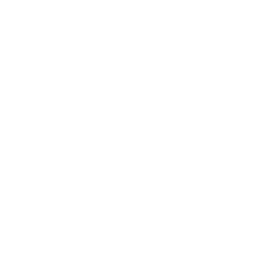
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Markkinaregiimien tunnistaminen</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Kvantitatiivinen rahoitus / Varainhoito &nbsp;|&nbsp; Maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto

Tämä esimerkki käyttää **PROC ACECLUS** -proseduuria löytämään latentin rakenteen, joka erottaa markkinaregiimit toisistaan, ja klusteroi sen perusteella. 100 viikoittaisesta havainnosta, jotka sisältävät 10 markkinapiirrettä (osaketuotto ja volatiliteetti, luotto- ja high yield -korkoerot, 2v/10v-korkokäyrä, dollari, hyödykkeet ja VIX-muutos), ACECLUS estimoi likimääräisen regiimin sisäisen kovarianssin *ilman* mitään regiimimerkintää ja johtaa kanoniset muuttujat, joita pitkin regiimit erottuvat toisistaan.

P=0.02-kynnyksellä algoritmi konvergoi kahdessa iteraatiossa ja säilyttää **kolme kanonista ulottuvuutta**, jotka yhdessä selittävät koko regiimien välisen hajonnan (ominaisarvojen osuudet 57.8%, 24.4%, 17.8%). Löyhempi P=0.05-kynnys ylitasoittaa kovarianssin ja **romahduttaa rakenteen yhteen ulottuvuuteen** — hyödyllinen muistutus siitä, että kynnys muokkaa tulosta olennaisesti.

Kolmen kanonisen muuttujan syöttäminen **PROC FASTCLUS** -proseduuriin (k=4) tuottaa 100 viikolle selkeän stressin voimakkuuden mukaisen järjestyksen (kokonais-R² = 0.51, pseudo-F = 33.2): 62 viikon rauhallinen ydin, 22 viikon toipuva/volatiliteetiltaan laskeva ryhmä, 12 viikon kohonneen stressin ryhmä ja 4 viikon syvän kriisin ryhmä, jonka high yield -korkoerot ovat keskimäärin noin 1 514 bps. Nämä sijoittelut viedään ulos myöhempää salkun riskiehdollistamista varten.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Viikoittaiset markkinapiirteiden havainnot eri omaisuusluokista | 100 |
| Muuttujat: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

Sarja on generoitu viisitilaisella Markov-regiiminvaihtoprosessilla (nousumarkkinan laajentuminen, syklin loppuvaihe, riskin välttäminen, kriisi, toipuminen), jossa piirteiden jakaumat ovat regiimiehdollisia. Ilman lisenssiä ajettaessa piirretaulukko rajataan ensimmäisiin 100 viikoittaiseen havaintoon (~2 vuotta) — nousumarkkinapainotteinen ikkuna, joka käy myös lyhyessä kriisissä ja toipumisessa. Viikoittaiset tuotot ja tasomuutokset edustavat viikon lopun hinnanmuutoksia; korkoerot ovat peruspisteinä ja volatiliteetti on VIX-tyyppinen indeksi.

---

In [1]:
/* --------------------------------------------------------
   Generate a weekly multi-asset market history with five
   embedded regime states driven by a Markov switching
   process. This worked example runs unlicensed, so the
   feature table below is capped at the first 100 weekly
   observations (~2 years) -- a bull-dominated window
   punctuated by a short crisis and recovery.
   -------------------------------------------------------- */
TIEDOT work.market_weekly;
    CALL streaminit(42);
    /* 5 regimes: 1=Bull, 2=Late-Cycle, 3=Risk-Off, 4=Crisis, 5=Recovery */
    TAULUKKO regime_names[5] $16 _temporary_
        ('NOUSUKAUSI' 'SYKLIN_LOPPU' 'RISKIPAKO'
         'KRIISI' 'ELPYMINEN');
    PIDÄ current_regime 1;
    TEE week_id = 1 ASTI 5000;
        /* Markov regime switching */
        u = rand('uniform');
        JOS current_regime = 1 NIIN TEE; /* Bull: long-lived */
            JOS u > 0.97 NIIN current_regime = 2;
        LOPPU;
        MUUTEN JOS current_regime = 2 NIIN TEE; /* Late-cycle */
            JOS u > 0.92 NIIN current_regime = 3;
        LOPPU;
        MUUTEN JOS current_regime = 3 NIIN TEE; /* Risk-off */
            JOS u > 0.80 NIIN current_regime = 4;
            MUUTEN JOS u < 0.10 NIIN current_regime = 1;
        LOPPU;
        MUUTEN JOS current_regime = 4 NIIN TEE; /* Crisis: short */
            JOS u > 0.75 NIIN current_regime = 5;
        LOPPU;
        MUUTEN JOS current_regime = 5 NIIN TEE; /* Recovery */
            JOS u > 0.85 NIIN current_regime = 1;
        LOPPU;
        regime_label = regime_names[current_regime];
        /* Regime-conditional feature distributions */
        JOS current_regime = 1 NIIN TEE;  /* Bull */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        LOPPU;
        MUUTEN JOS current_regime = 2 NIIN TEE;  /* Late-cycle */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        LOPPU;
        MUUTEN JOS current_regime = 3 NIIN TEE;  /* Risk-off */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        LOPPU;
        MUUTEN JOS current_regime = 4 NIIN TEE;  /* Crisis */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        LOPPU;
        MUUTEN TEE;  /* Recovery */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        LOPPU;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        JOS week_id = 1 NIIN vix_chg = 0;
        TULOSTE;
    LOPPU;
    NIMIKE week_id="Viikon tunniste"
          regime_label="Markkinaregiimi"
          eq_return_pct="Osakkeiden viikkotuotto (%)"
          eq_vol_idx="Osakevolatiliteetti-indeksi"
          credit_spread_bps="Luottoriskilisä (bps)"
          hy_spread_bps="High yield -riskilisä (bps)"
          yield_2y="2 vuoden korko (%)"
          yield_10y="10 vuoden korko (%)"
          term_spread="Korkoero (10v-2v)"
          usd_index_chg="USD-indeksin muutos"
          commodities_ret="Hyödykkeiden tuotto"
          vix_chg="VIX-muutos";
    POISTA u;
    NIMEÄ_UUDELLEEN credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
SUORITA;


NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.33 seconds
  cpu   1.33 seconds


---

In [2]:
/* Markkinapiirteiden lähtötaso regiimeittäin */
OTSIKKO "Markkinapiirteiden lähtötaso regiimeittäin";
PROSEDUURI KESKIARVOT TIEDOT=work.market_weekly n mean std MIN MAX;
    LUOKKA regime_label;
    MUUTTUJA eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    NIMIKE regime_label="Markkinaregiimi"
          eq_return_pct="Osakkeiden viikkotuotto (%)"
          eq_vol_idx="Osakevolatiliteetti-indeksi"
          credit_spread_bps="Luottoriskilisä (bps)"
          hy_spread_bps="High yield -riskilisä (bps)"
          term_spread="Korkoero (10v-2v)"
          vix_chg="VIX-muutos";
SUORITA;


                                       Markkinapiirteiden lähtötaso regiimeittäin                                       

                                                  The MEANS Procedure

                             Analysis Variable : eq_return_pct Osakkeiden viikkotuotto (%)

        Markkinaregiimi          N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------
        ELPYMINEN                    4      0.0077500      1.5951747     -0.8330000      2.4000000
        KRIISI                      12     -2.3403333      3.9436692     -8.0160000      3.7360000
        NOUSUKAUSI                  28      0.2860000      1.0226518     -1.5980000      2.2150000
        RISKIPAKO                   17     -0.8447059      1.2832441     -3.3850000      1.1810000
        SYKLIN_LOPPU                39      0.0364359      1.9733801     -4.6010000      3.7030000
        --------------


NOTE: Option TITLE changed to Markkinapiirteiden lähtötaso regiimeittäin.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                       Markkinapiirteiden lähtötaso regiimeittäin                                       




NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


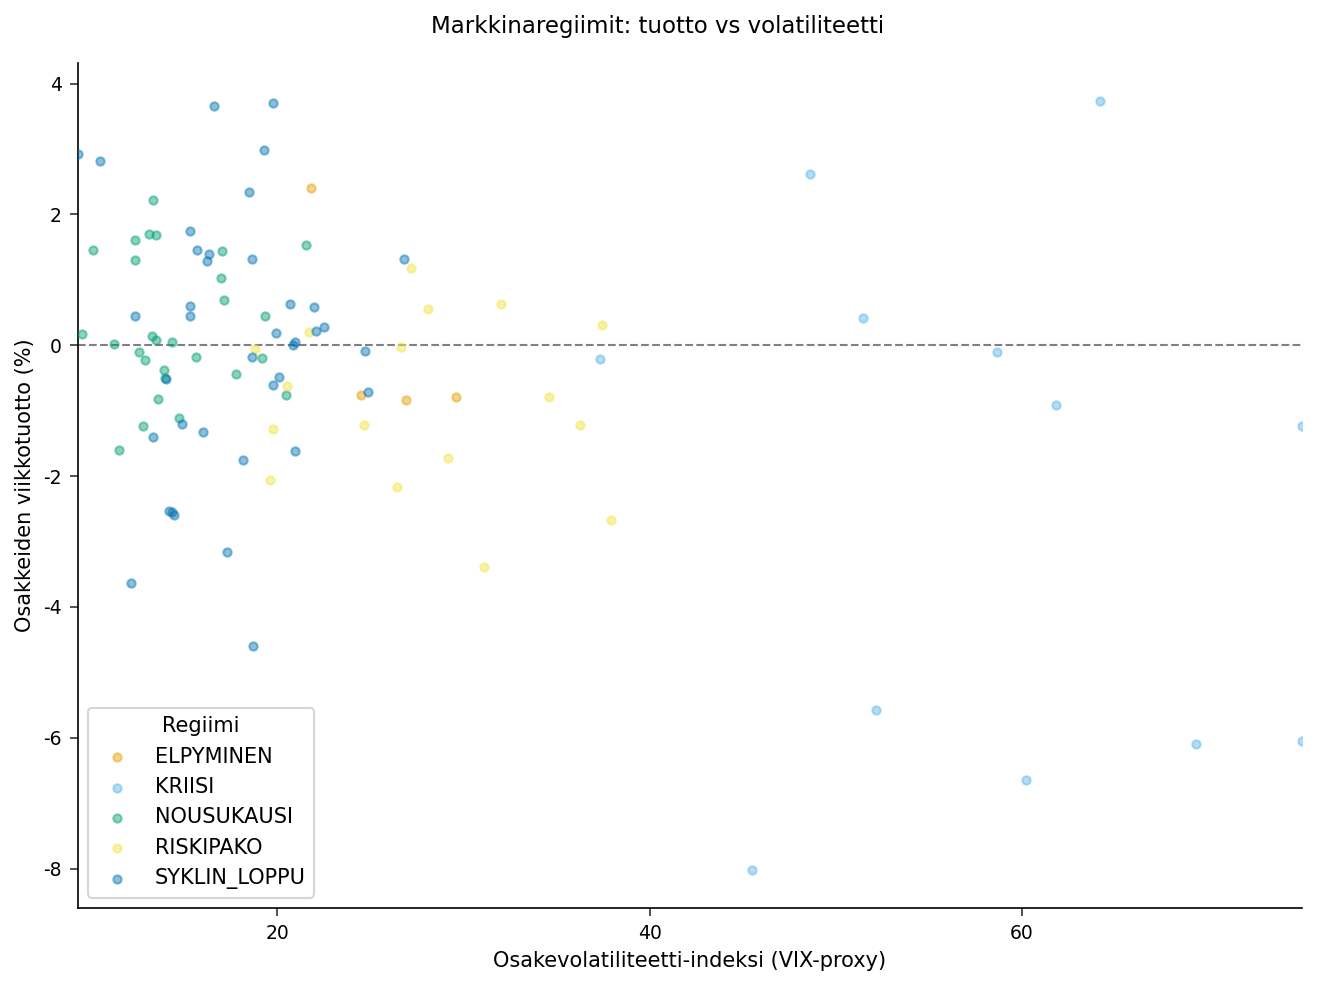

In [3]:
/* Osaketuotto vs volatiliteetti-indeksi regiimeittäin */
PROSEDUURI SGPLOT TIEDOT=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS NIMIKE="Osakevolatiliteetti-indeksi (VIX-proxy)";
    YAXIS NIMIKE="Osakkeiden viikkotuotto (%)";
    keylegend / OTSIKKO="Regiimi";
    OTSIKKO "Markkinaregiimit: tuotto vs volatiliteetti";
SUORITA;


---

In [4]:
/* --------------------------------------------------------
   Regiimin sisäisen kovarianssin likimääräinen estimointi.
   ACECLUS estimoi klustereiden sisäisen yhteiskovarianssin
   ilman klusterimerkintöjä ja johtaa kanoniset muuttujat,
   jotka erottavat regiimit. P=0,02 asettaa parittaisen
   etäisyyskynnyksen: vain lähimmät ~2 % havaintopareista
   käsitellään samaan regiimiin kuuluvina.
   -------------------------------------------------------- */
OTSIKKO "ACECLUS: regiimin sisäinen kovarianssi (P=0,02)";
PROSEDUURI aceclus TIEDOT=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    MUUTTUJA eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
SUORITA;


                                    ACECLUS: regiimin sisäinen kovarianssi (P=0,02)                                     

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
Osakkeiden viikkotuotto (%)      -0.3298       2.1334
Osakevolatiliteetti-indeksi      23.7341      14.7118
Luottoriskilisä (bps)     171.1000     118.0522
High yield -riskilisä (bps)     596.2100     341.1657
2 vuoden korko (%)         2.8713       1.4029
10 vuoden korko (%)        3.1472       1.0815
Korkoero (10v-2v)          0.2697       0.9969
USD-indeksin muutos       -0.0184       0.8046
Hyödykkeiden tuotto       -0.3444       1.3444
VIX-muutos          


NOTE: Option TITLE changed to ACECLUS: regiimin sisäinen kovarianssi (P=0,02).
NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Herkkyystarkastelu arvolla P=0,05 -- väljempi
   samaan-regiimiin-kynnys vetää mukaan enemmän pareja ja
   kasvattaa estimoitua regiimin sisäistä kovarianssia.
   Vertaa kanonista rakennetta (ominaisarvot ja säilytetyt
   ulottuvuudet) P=0,02-ratkaisuun.
   -------------------------------------------------------- */
OTSIKKO "ACECLUS-herkkyystarkastelu (P=0,05)";
PROSEDUURI aceclus TIEDOT=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    MUUTTUJA eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
SUORITA;


                                          ACECLUS-herkkyystarkastelu (P=0,05)                                           

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
Osakkeiden viikkotuotto (%)      -0.3298       2.1334
Osakevolatiliteetti-indeksi      23.7341      14.7118
Luottoriskilisä (bps)     171.1000     118.0522
High yield -riskilisä (bps)     596.2100     341.1657
2 vuoden korko (%)         2.8713       1.4029
10 vuoden korko (%)        3.1472       1.0815
Korkoero (10v-2v)          0.2697       0.9969
USD-indeksin muutos       -0.0184       0.8046
Hyödykkeiden tuotto       -0.3444       1.3444
VIX-muutos          


NOTE: Option TITLE changed to ACECLUS-herkkyystarkastelu (P=0,05).
NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   K-means ACECLUS-kanonisilla muuttujilla. ACECLUS säilytti
   kolme kanonista ulottuvuutta (Can1-Can3), joten
   klusterointi ajetaan niillä. Neljä klusteria tähtää
   neljään hyvin edustettuun markkinatilaan.
   -------------------------------------------------------- */
OTSIKKO "K-means-klusterointi kanonisilla muuttujilla";
PROSEDUURI FASTCLUS TIEDOT=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    MUUTTUJA can1 can2 can3;
SUORITA;


                                      K-means-klusterointi kanonisilla muuttujilla                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4


NOTE: Option TITLE changed to K-means-klusterointi kanonisilla muuttujilla.
NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                         Regiimiklusteri vs todellinen regiimi                                          

                                                   The FREQ Procedure

Table of Klusteri by Markkinaregiimi

Klusteri |   ELPYMINEN |      KRIISI |  NOUSUKAUSI |   RISKIPAKO |SYKLIN_LOPPU |        Total
---------+-------------+-------------+-------------+-------------+-------------+-------------
1        |           0 |           4 |           2 |           4 |           2 |           12
         |        0.00 |        4.00 |        2.00 |        4.00 |        2.00 |        12.00
---------+-------------+-------------+-------------+-------------+-------------+-------------
2        |           3 |           3 |          21 |           7 |          28 |           62
         |        3.00 |        3.00 |       21.00 |        7.00 |       28.00 |        62.00
---------+-------------+-------------+-------------+-------------+-------------+-------------
3        |       


NOTE: Option TITLE changed to Regiimiklusteri vs todellinen regiimi.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


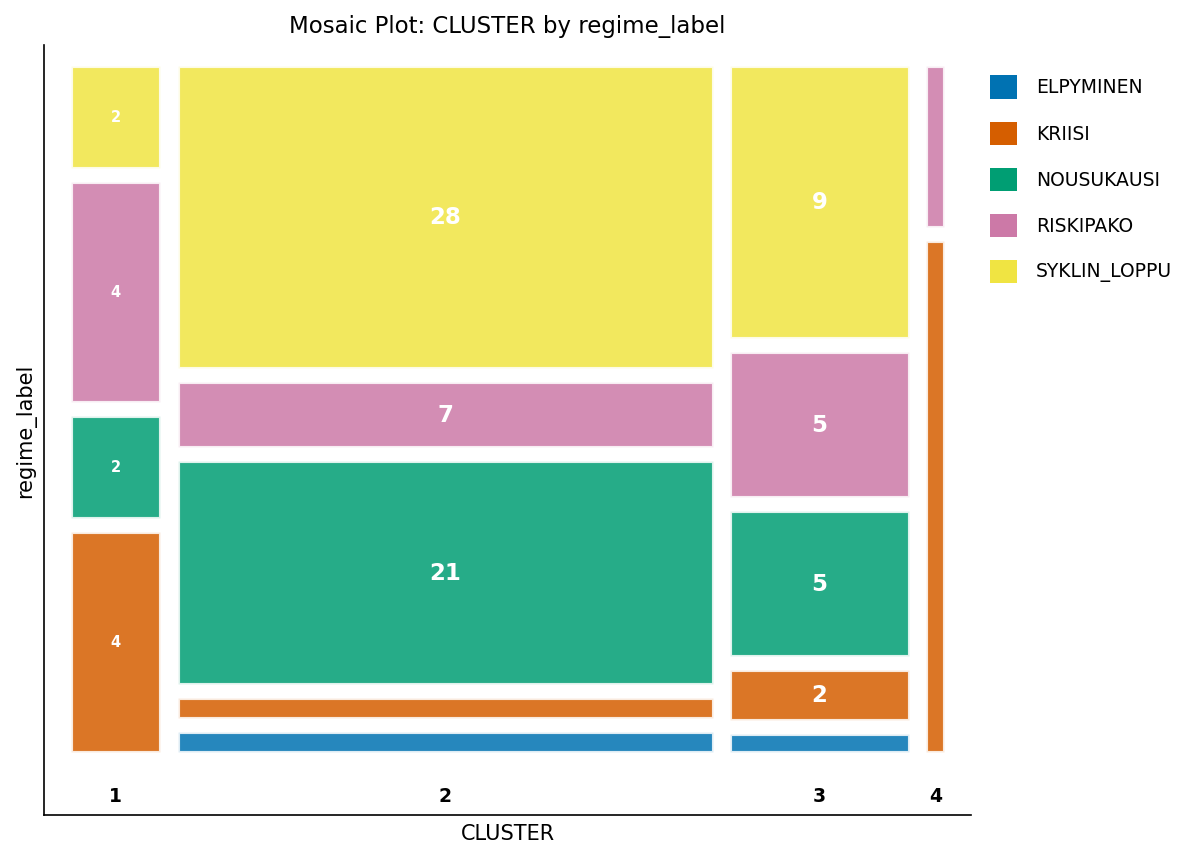

In [7]:
/* --------------------------------------------------------
   Validoi määritetyt klusterit tunnettuja
   regiimimerkintöjä vasten
   -------------------------------------------------------- */
OTSIKKO "Regiimiklusteri vs todellinen regiimi";
PROSEDUURI FREKVENSSIT TIEDOT=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    NIMIKE CLUSTER="Klusteri" regime_label="Markkinaregiimi";
SUORITA;


In [8]:
/* --------------------------------------------------------
   Profiloi regiimipiirteiden keskiarvot tulkintaa varten
   -------------------------------------------------------- */
OTSIKKO "Regiimipiirteiden keskiarvot klustereittain";
PROSEDUURI KESKIARVOT TIEDOT=work.regime_assignments mean;
    LUOKKA CLUSTER;
    MUUTTUJA eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    NIMIKE CLUSTER="Klusteri"
          eq_return_pct="Osakkeiden viikkotuotto (%)"
          eq_vol_idx="Osakevolatiliteetti-indeksi"
          credit_spread_bps="Luottoriskilisä (bps)"
          hy_spread_bps="High yield -riskilisä (bps)"
          term_spread="Korkoero (10v-2v)"
          vix_chg="VIX-muutos";
SUORITA;


                                      Regiimipiirteiden keskiarvot klustereittain                                       

                                                  The MEANS Procedure

                                            Analysis Variable : eq_return_pct Osakkeiden viikkotuotto (%)

                                                          N
                                            Klusteri    Obs            Mean
                                            -------------------------------
                                            1            12      -2.0955000
                                            2            62      -0.3638871
                                            3            22       0.7421364
                                            4             4      -0.4010000
                                            -------------------------------

                                            Analysis Variable : eq_vol_idx Osakevolatiliteetti-indeksi

   


NOTE: Option TITLE changed to Regiimipiirteiden keskiarvot klustereittain.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Tulkinta

**ACECLUS-kanoninen rakenne.** 100 viikon otoksessa PROC ACECLUS (P=0.02, kynnys = 2.578941) konvergoi kahdessa iteraatiossa ja tuotti kolme kanonista muuttujaa. Niiden `Inv(ACE)*(COV-ACE)` -ominaisarvot ovat 0.0219, 0.0093 ja 0.0067, eli osuudet 57.8%, 24.4% ja 17.8% (kumulatiivinen 100%). Ensimmäinen kanoninen akseli kantaa hallitsevaa risk-on/risk-off-kontrastia; toinen ja kolmas tarkentavat sitä. Koska osakevolatiliteetti- ja korkoeropiirteet liikkuvat voimakkaasti yhdessä, ACECLUS sisällyttää tämän jaetun vaihtelun regiimin sisäiseen kovarianssiin, jolloin kanoniset akselit heijastavat aitoa regiimien välistä erottelua eivätkä yhteistä skaalaa.

**Kynnysherkkyys.** Uudelleenajo P=0.05:llä nostaa etäisyyskynnyksen arvoon 2.899704, mikä vetää 4 949 kaikkiaan 4 950 havaintoparista rajan sisäpuolelle. Estimoitu regiimin sisäinen kovarianssi on tällöin lähes yhtä suuri kuin kokonaiskovarianssi, ja kanoninen rakenne **romahtaa yhteen ulottuvuuteen** (yksi ominaisarvo, 0.0096, osuudella 100%). P=0.02- ja P=0.05-ratkaisut eivät siis ole tässä keskenään vaihtokelpoisia — löyhempi kynnys pyyhkii pois hienommat regiimiakselit, joten tiukempi kynnys on tämän otoksen informatiivisempi määrittely.

**Klusterointi kanonisten muuttujien perusteella.** PROC FASTCLUS (k=4) muuttujilla Can1–Can3 antaa kokonais-R²:n 0.5089 ja pseudo-F:n 33.16. Can2 tekee suurimman osan erottelutyöstä (R² = 0.626), Can1 vaikuttaa kohtalaisesti (R² = 0.359), ja Can3 ei lisää käytännössä mitään (R² = 0.000) — mikä on linjassa sen kanssa, että vain kaksi akselia kantaa vahvaa signaalia. Neljä klusteria asettuvat markkinastressin gradientiksi:

| Klusteri | n | Osaketuoton ka. | VIX:n ka. | HY-korkoeron ka. | VIX-muutoksen ka. | Tulkinta |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | Rauhallinen ydin (nousumarkkina / syklin loppuvaihe) |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | Toipuva, volatiliteetti laskee |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | Kohonnut stressi, volatiliteetti nousee jyrkästi |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | Syvä kriisi, äärimmäinen luottostressi |

**Klusteri vs. todellinen regiimi.** Ristiintaulukointi osoittaa, että klusterit eivät kuvaudu yksi yhteen viiteen generoivaan merkintään — mikä on odotettua, koska merkinnät menevät piirreavaruudessa voimakkaasti päällekkäin tällä otoskoolla. Suuri rauhallinen klusteri (62) imee itseensä suurimman osan nousumarkkina- (21) ja syklin loppuvaiheen (28) viikoista; syvän kriisin klusteri (4) koostuu lähes kokonaan äärimmäisimmistä kriisiviikoista (3 neljästä). Kanoniset akselit järjestävät viikot siten *voimakkuuden* eivätkä tarkan merkinnän mukaan, mikä on riskin ehdollistamisen kannalta käyttökelpoisempi signaali.

**Käyttö.** Ulos viedyt viikoittaiset sijoittelut tukevat taktista ehdollistamista: kevennä riskiä ja pidennä duraatiota, kun viikot siirtyvät kohti klustereita 1 ja 4, ja lisää riskiä uudelleen, kun ne palaavat rauhalliseen ytimeen (klusteri 2) tai toipuvaan ryhmään (klusteri 3).


---

In [9]:
/* --------------------------------------------------------
   Export weekly regime assignments for portfolio
   risk model conditioning and signal generation
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>-alustalla
</div>
</div>